# Classical Motion Deblurring Evaluation

This notebook visualizes the metrics and outputs from the classical motion deblurring filters.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import os

base_dir = r"A:\HUST_on_GitHub\ProjectCV"
eval_csv = os.path.join(base_dir, "outputs", "motion_deblur", "final_eval", "metrics_summary.csv")

if os.path.exists(eval_csv):
    df = pd.read_csv(eval_csv)
    print("Metrics Summary:")
    display(df)
else:
    print(f"Could not find {eval_csv}. Run evaluate_motion_deblur.py first.")

Metrics Summary:


,Method,PSNR,SSIM,MS-SSIM,LPIPS,MAE,MSE,BRISQUE,NIQE,PIQE,Entropy
0,FergusBlind_Default,15.991782,0.333470,0.333470,0.483127,27.673534,1859.642827,39.611823,4.984802,27.820321,7.636434
1,Raw_Blurry,29.063899,0.863433,0.863433,0.183963,5.790693,142.952818,45.329938,5.941613,61.621944,7.556420
2,RichardsonLucy_Default,22.355594,0.641227,0.641227,0.277735,12.419499,472.176299,43.385498,5.638160,54.089470,7.610277
3,Wiener_Default,15.991782,0.333470,0.333470,0.483127,27.673534,1859.642827,39.611823,4.984802,27.820321,7.636434


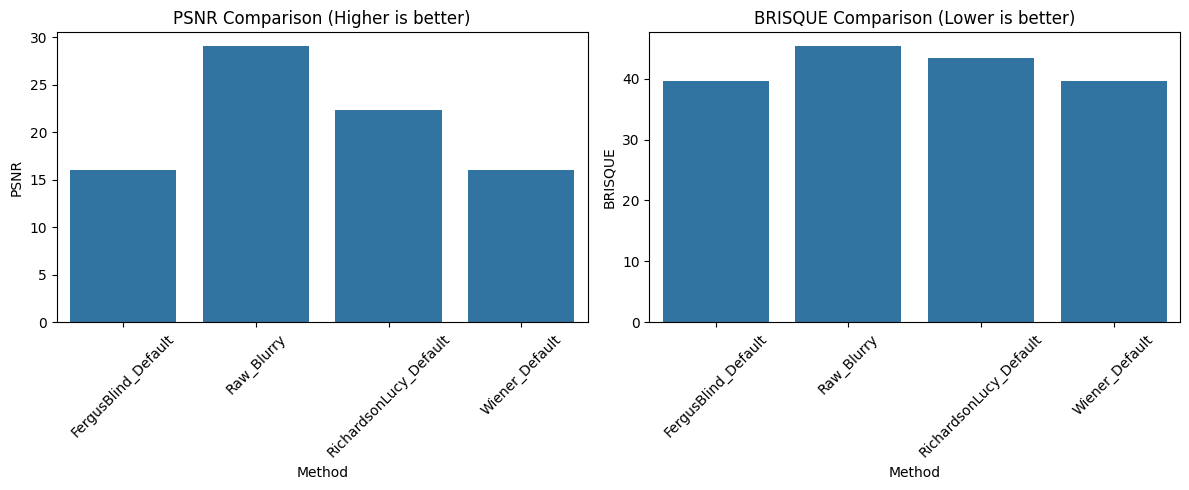

In [2]:
if 'df' in locals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    sns.barplot(data=df, x='Method', y='PSNR', ax=axes[0])
    axes[0].set_title("PSNR Comparison (Higher is better)")
    axes[0].tick_params(axis='x', rotation=45)
    
    sns.barplot(data=df, x='Method', y='BRISQUE', ax=axes[1])
    axes[1].set_title("BRISQUE Comparison (Lower is better)")
    axes[1].tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.show()

## Visualizing Output Samples

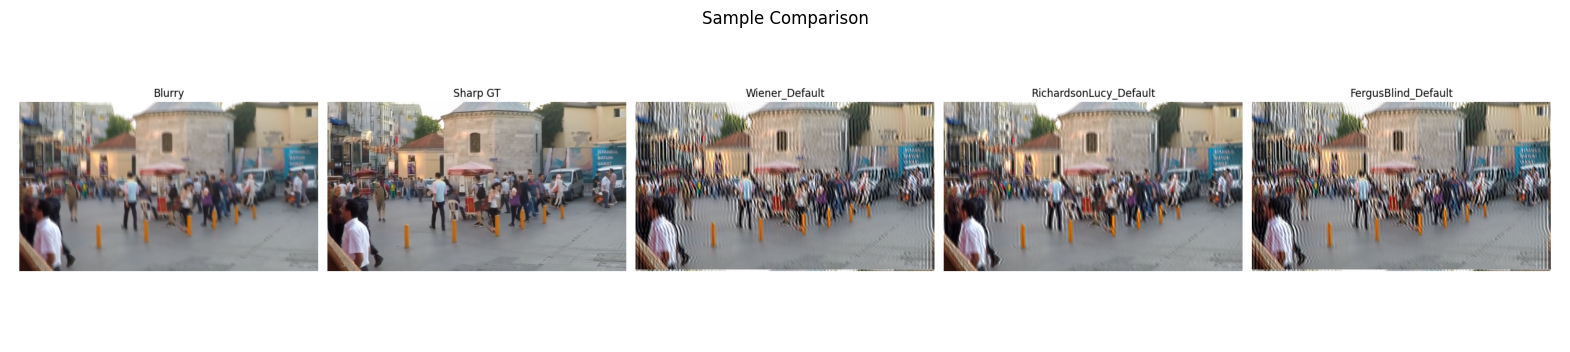

In [3]:
vis_dir = os.path.join(base_dir, "outputs", "motion_deblur", "visual_comparison")
if os.path.exists(vis_dir):
    vis_files = [f for f in os.listdir(vis_dir) if f.endswith(".png")]
    if len(vis_files) > 0:
        sample = os.path.join(vis_dir, vis_files[0])
        img = cv2.imread(sample)
        img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.figure(figsize=(20, 10))
        plt.imshow(img_rgb)
        plt.axis('off')
        plt.title("Sample Comparison")
        plt.show()
    else:
        print("No visualizations found. Run visualize_motion_results.py first.")
else:
    print("Visualization directory not found.")